In [10]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/thedevastator/books-sales-and-ratings/Books_Data_Clean.csv


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv("/kaggle/input/datasets/thedevastator/books-sales-and-ratings/Books_Data_Clean.csv")

In [13]:
df.head()

,index,Publishing Year,Book Name,Author,language_code,Author_Rating,Book_average_rating,Book_ratings_count,genre,gross sales,publisher revenue,sale price,sales rank,Publisher,units sold
0,0,1975.0,Beowulf,"Unknown, Seamus Heaney",en-US,Novice,3.42,155903,genre fiction,34160.0,20496.0,4.88,1,HarperCollins Publishers,7000
1,1,1987.0,Batman: Year One,"Frank Miller, David Mazzucchelli, Richmond Lew...",eng,Intermediate,4.23,145267,genre fiction,12437.5,7462.5,1.99,2,HarperCollins Publishers,6250
2,2,2015.0,Go Set a Watchman,Harper Lee,eng,Novice,3.31,138669,genre fiction,47795.0,28677.0,8.69,3,"Amazon Digital Services, Inc.",5500
3,3,2008.0,When You Are Engulfed in Flames,David Sedaris,en-US,Intermediate,4.04,150898,fiction,41250.0,24750.0,7.50,3,Hachette Book Group,5500
4,4,2011.0,Daughter of Smoke & Bone,Laini Taylor,eng,Intermediate,4.04,198283,genre fiction,37952.5,22771.5,7.99,4,Penguin Group (USA) LLC,4750


In [14]:
df.describe() 

,index,Publishing Year,Book_average_rating,Book_ratings_count,gross sales,publisher revenue,sale price,sales rank,units sold
count,1070.000000,1069.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000,1070.000000
mean,534.500000,1971.377923,4.007000,94909.913084,1856.622944,843.281030,4.869561,611.652336,9676.980374
std,309.026698,185.080257,0.247244,31513.242518,3936.924240,2257.596743,3.559919,369.849830,15370.571306
min,0.000000,-560.000000,2.970000,27308.000000,104.940000,0.000000,0.990000,1.000000,106.000000
25%,267.250000,1985.000000,3.850000,70398.000000,372.465000,0.000000,1.990000,287.500000,551.250000
50%,534.500000,2003.000000,4.015000,89309.000000,809.745000,273.078000,3.990000,595.500000,3924.000000
75%,801.750000,2010.000000,4.170000,113906.500000,1487.957500,721.180500,6.990000,932.500000,5312.250000
max,1069.000000,2016.000000,4.770000,206792.000000,47795.000000,28677.000000,33.860000,1273.000000,61560.000000


In [15]:
df = df[df["Publishing Year"]>1900]
# This line filters the DataFrame and keeps only the rows, df["Publishing Year"] > 1900 creates a True/False mask.
#df[...] selects only the rows where the condition is True. df = saves the filtered result back into df

In [16]:
df.isna().sum()

index                   0
Publishing Year         0
Book Name              21
Author                  0
language_code          49
Author_Rating           0
Book_average_rating     0
Book_ratings_count      0
genre                   0
gross sales             0
publisher revenue       0
sale price              0
sales rank              0
Publisher               0
units sold              0
dtype: int64

In [17]:
df.dropna(subset ="Book Name",inplace=True)
#dropna() removes rows containing missing (NaN) values.
#subset="Book Name" checks only the Book Name column for missing values.
#inplace=True updates the original DataFrame directly instead of creating a new one


In [18]:
df.duplicated().sum()

np.int64(0)

In [19]:
df.nunique()

index                  988
Publishing Year        101
Book Name              987
Author                 669
language_code            8
Author_Rating            4
Book_average_rating    133
Book_ratings_count     983
genre                    4
gross sales            774
publisher revenue      570
sale price             143
sales rank             818
Publisher                9
units sold             470
dtype: int64

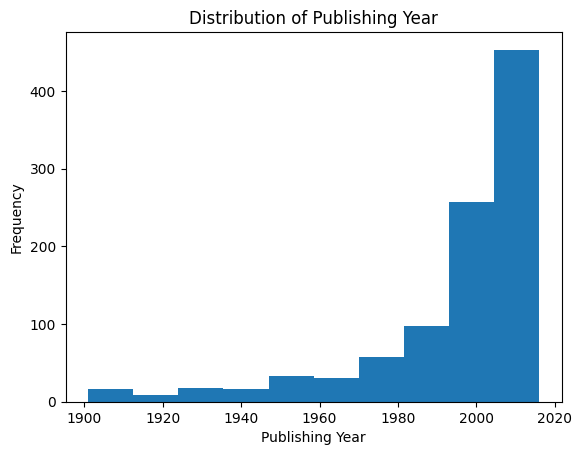

In [20]:
plt.hist(df["Publishing Year"]) #Draws bars showing how many books were published in each year.
plt.xlabel("Publishing Year") #Writes "Publishing Year" below the x-axis so the reader knows what those numbers represent.
plt.ylabel("Frequency")
plt.title("Distribution of Publishing Year")
plt.show()

In [21]:
df["Publishing Year"].describe()
df["genre"].describe()

count               988
unique                4
top       genre fiction
freq                759
Name: genre, dtype: object

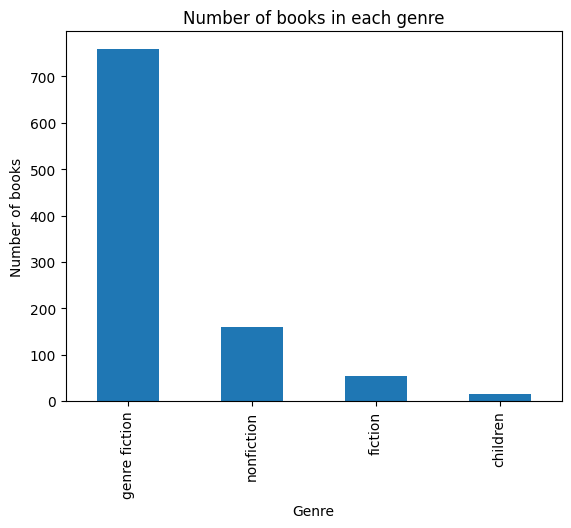

In [22]:
#plt.hist(df["genre"]) #Continuous/Numeric data (Age, Salary, Height, Publishing Year)
#Matplotlib internally categories ko numbers mein convert karke histogram bana deta hai. Isliye tumhe bars dikh rahi hain.
df["genre"].value_counts().plot(kind = "bar") #Categorical data (Genre, Language, Author)
plt.xlabel("Genre")
plt.ylabel("Number of books")
plt.title("Number of books in each genre")
plt.show()

In [23]:
df.groupby("Author")["Book_average_rating"].mean().sort_values(ascending=False) # Groups data by Author and calculates the average Book_average_rating for each author , it is a pandas series

Author
Bill Watterson                  4.650000
Bill Watterson, G.B. Trudeau    4.610000
J.R.R. Tolkien                  4.590000
George R.R. Martin              4.560000
Sarah J. Maas                   4.526000
                                  ...   
Chetan Bhagat                   3.273333
Audrey Niffenegger              3.230000
Herman Koch, Sam Garrett        3.220000
P.D. James                      3.210000
Sue Monk Kidd                   3.100000
Name: Book_average_rating, Length: 669, dtype: float64

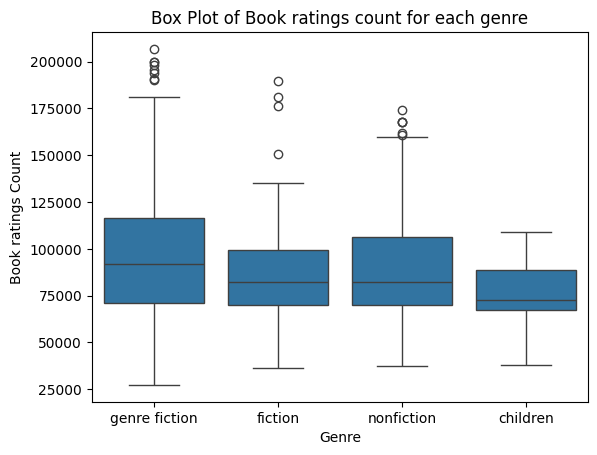

In [24]:
sns.boxplot(x="genre", y="Book_ratings_count", data=df)
plt.xlabel("Genre")
plt.ylabel("Book ratings Count")
plt.title("Box Plot of Book ratings count for each genre")
plt.show()
#x="genre" → X-axis par alag-alag genres (Fiction, Romance, Mystery, etc.) dikhaye jayenge.
#y="Book_ratings_count" → Y-axis par har book ke ratings ki count hogi.
#data=df → Data df DataFrame se liya jayega.
#sns.boxplot(...) → Har genre ke liye ratings count ka distribution (minimum, maximum, median, quartiles, outliers) dikhata hai.

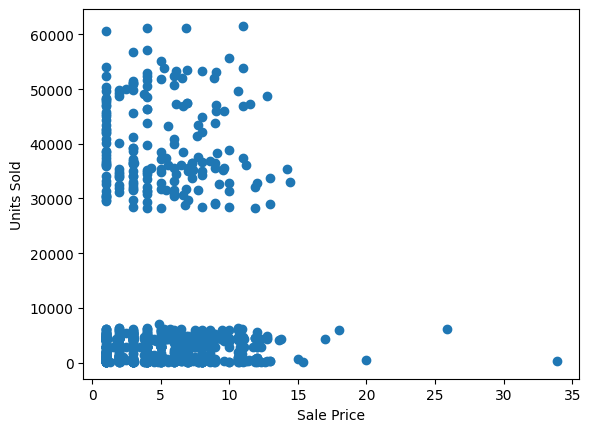

In [25]:
plt.scatter(df["sale price"],df["units sold"])
plt.xlabel("Sale Price")
plt.ylabel("Units Sold")
plt.show()

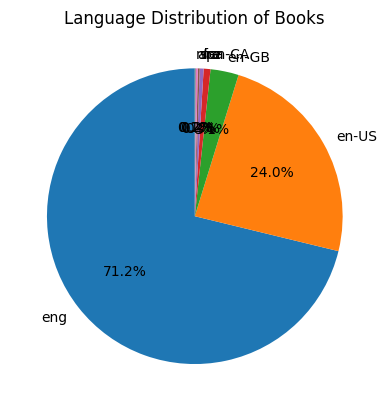

In [26]:
language_counts = df["language_code"].value_counts()
plt.pie(language_counts,labels=language_counts.index,startangle=90, autopct = "%1.1f%%")
plt.title("Language Distribution of Books")
plt.show()
#language_counts = values (kitni books), labels = language names, startangle=90 = chart top se start hoga, autopct = har slice par percentage dikhayega.

In [27]:
df.groupby("Publisher ")["publisher revenue"].sum().sort_values(ascending = False)
#groupby() kabhi bhi khud se sum, mean ya count nahi karta. Ye sirf grouping karta hai.

Publisher 
Penguin Group (USA) LLC                 191581.104
Random House LLC                        174956.244
Amazon Digital Services,  Inc.          141767.772
HarperCollins Publishers                121769.814
Hachette Book Group                     107410.968
Simon and Schuster Digital Sales Inc     46858.206
Macmillan                                31249.830
HarperCollins Publishing                  2830.806
HarperCollins Christian Publishing        2135.670
Name: publisher revenue, dtype: float64

In [28]:
df.groupby("Author_Rating")["Book_ratings_count"].mean().sort_values(ascending=True)

Author_Rating
Excellent        83804.800595
Novice           87318.464286
Famous           98295.250000
Intermediate    101400.272569
Name: Book_ratings_count, dtype: float64

In [29]:
df.groupby("language_code").size().sort_values(ascending=False)

language_code
eng      670
en-US    226
en-GB     29
en-CA      7
fre        4
ara        2
spa        2
nl         1
dtype: int64

In [31]:
df.groupby("Author_Rating")["Book_ratings_count"].max()
#groupby("Author_Rating") → Groups all rows that have the same Author_Rating together.
#["Book_ratings_count"] → Selects the Book_ratings_count column.

Author_Rating
Excellent        83804.800595
Famous           98295.250000
Intermediate    101400.272569
Novice           87318.464286
Name: Book_ratings_count, dtype: float64

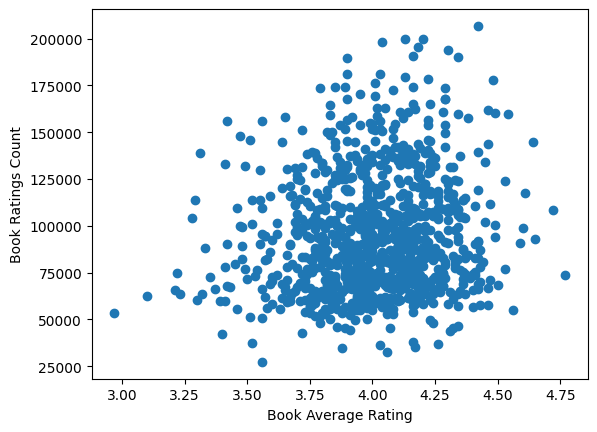

In [33]:
plt.scatter(df["Book_average_rating"],df["Book_ratings_count"])
plt.xlabel("Book Average Rating")
plt.ylabel("Book Ratings Count")
plt.show()

In [36]:
df.columns

Index(['index', 'Publishing Year', 'Book Name', 'Author', 'language_code',
       'Author_Rating', 'Book_average_rating', 'Book_ratings_count', 'genre',
       'gross sales', 'publisher revenue', 'sale price', 'sales rank',
       'Publisher ', 'units sold'],
      dtype='object')

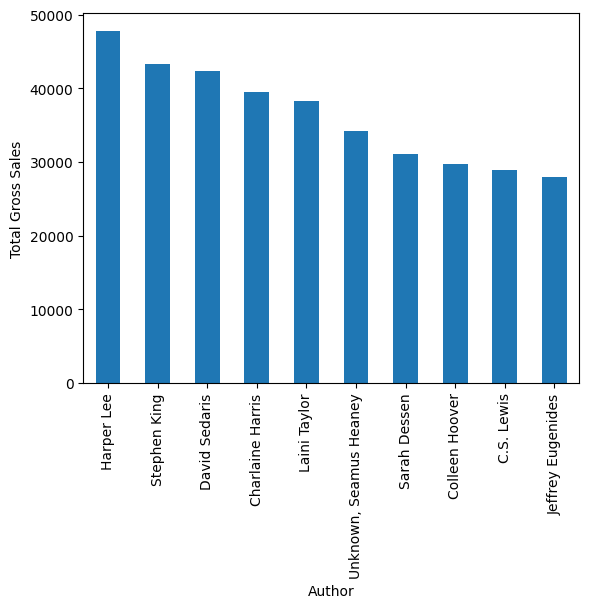

In [41]:
df.groupby("Author")["gross sales"].sum().sort_values(ascending=False).head(10).plot(kind="bar")
plt.ylabel("Total Gross Sales")
plt.show()

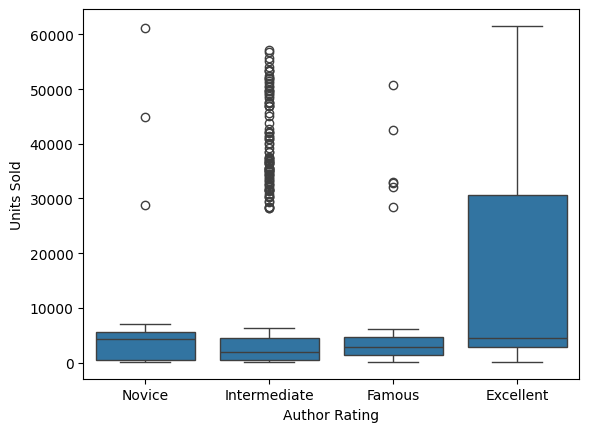

In [42]:
sns.boxplot(x="Author_Rating", y="units sold", data =df)
plt.xlabel("Author Rating")
plt.ylabel("Units Sold")
plt.show()

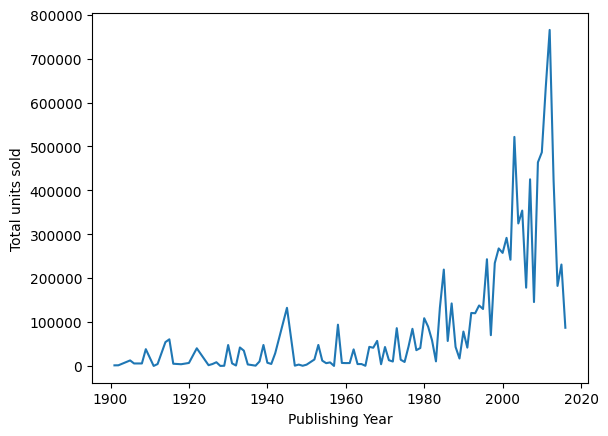

In [43]:
df.groupby("Publishing Year")["units sold"].sum().plot(kind="line")
plt.xlabel("Publishing Year")
plt.ylabel("Total units sold")
plt.show()